In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Add, Concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import tensorflow as tf


In [2]:
# During the Adaptation phase, all network weights are frozen except the last layer
# (the one with softmax), whose weights are updated.
# Consequence: limited adaptation.


# ======= RESNET DEFINITION ======= #

def create_resnet(input_dim, num_classes, dropout_pcg=0.25, factors=256):
    inp = Input(shape=(input_dim,))

    # First "base" block
    out = Dense(factors, activation="relu")(inp)
    out = BatchNormalization()(out)
    out = Dropout(dropout_pcg)(out)

    # "Residual" block
    res = Dense(factors, activation="relu")(out)
    res = BatchNormalization()(res)
    res = Dropout(dropout_pcg)(res)

    # Skip connection
    out = Add()([out, res])

    # Concatenation with original input
    out = Concatenate()([out, inp])

    # Softmax output
    out = Dense(num_classes, activation="softmax")(out)

    m = Model(inp, out)
    m.compile(
        loss="categorical_crossentropy",
        optimizer=tf.keras.optimizers.RMSprop(1e-3),
        metrics=["accuracy"]
    )
    return m


# ======= SEED FOR REPRODUCIBILITY ======= #

np.random.seed(42)
tf.random.set_seed(42)


# ======= OUTPUT DIRECTORIES ======= #

base_dir = r"C:\Users\franc\Desktop\GitHub\05-Test_4_Cross_Subject_Adaptation\4.1_last_dense_only"

results_dir = os.path.join(base_dir, "results")
os.makedirs(results_dir, exist_ok=True)

best_resnet_dir = os.path.join(base_dir, "best_model_resnet")
os.makedirs(best_resnet_dir, exist_ok=True)

merged_dir = os.path.join(base_dir, "merged_PSD_dataset")
os.makedirs(merged_dir, exist_ok=True)

log_path = os.path.join(
    results_dir,
    "RESNET_cross_subject_adaptation_last_dense_log.txt"
)



def print_and_save(text, f):
    print(text)
    f.write(text + "\n")


In [3]:
# ======= TRAINING DATASET (15 SUBJECT) ======= #

train_files = [
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_1.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_2.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_3.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_4.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_5.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_6.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_7.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_8.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_9.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_10.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_11.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_12.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_13.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_14.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_15.csv'
]

# Merge the 15 subjects datasets
df_list = [pd.read_csv(file) for file in train_files]
psd_15 = pd.concat(df_list, ignore_index=True)
psd_15.to_csv(os.path.join(merged_dir, "PSD_dataset_15.csv"), index=False)

In [4]:
# ======= TRAINING SET LOADING ======= #

df = psd_15

# PSD features (all columns except Event Id)
X = df.drop("Event Id", axis=1).astype(float).values
# Labels
y = df["Event Id"].values

input_dim = X.shape[1]

# Class mapping (derived ONLY from training data)
classes = np.array(sorted(np.unique(y)))
num_classes = len(classes)
to_index = {c: i for i, c in enumerate(classes)}


# ======= TRAIN/VALIDATION SPLIT ======= #

# Only for training
Xtr, Xval, ytr, yval = train_test_split(
    X, y,
    train_size=0.8,
    shuffle=True,
    stratify=y,
    random_state=42
)


# ======= SCALER ======= #

# Fit ONLY on training set (15 subjects)
scaler = MinMaxScaler().fit(Xtr)
Xtr_s  = scaler.transform(Xtr)
Xval_s = scaler.transform(Xval)


# ======= OVERSAMPLING ======= #

# ONLY on training set to avoid Data Leakage
df_tr = pd.DataFrame(Xtr_s)
df_tr["Event Id"] = ytr

max_n = df_tr["Event Id"].value_counts().max()
dfs = []
for cls, sub in df_tr.groupby("Event Id"):
    if len(sub) < max_n:
        sub = resample(sub, replace=True, n_samples=max_n, random_state=42)
    dfs.append(sub)

df_bal = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)
Xtr_bal = df_bal.drop("Event Id", axis=1).values
ytr_bal = df_bal["Event Id"].values


# ======= ONE-HOT ======= #

ytr_cat  = to_categorical([to_index[c] for c in ytr_bal], num_classes=num_classes)
yval_cat = to_categorical([to_index[c] for c in yval], num_classes=num_classes)

In [5]:
# ======= TRAINING ======= #

model = create_resnet(input_dim, num_classes)

ckpt_path_15 = os.path.join(best_resnet_dir, "best_resnet_15.weights.h5")
ckpt_15 = ModelCheckpoint(
    ckpt_path_15,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=0
)
rlr_15 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=0
)

model.fit(
    Xtr_bal, ytr_cat,
    validation_data=(Xval_s, yval_cat),
    epochs=150,
    batch_size=64,
    callbacks=[ckpt_15, rlr_15],
    verbose=0
)

# Load the best weights from training on the 15 subjects
model.load_weights(ckpt_path_15)

In [6]:
# ======= TEST DATASETS (12 NEW SUBJECTS) ======= #

test_files = [
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_16.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_17.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_18.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_19.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_20.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_21.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_22.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_23.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_24.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_25.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_26.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_27.csv'
]

In [7]:

# ======= MAIN LOOP ======= #

subjects_list = [] 

with open(log_path, "w", encoding="utf-8") as f:

    print_and_save("=" * 70, f)
    print_and_save("CROSS-SUBJECT ADAPTATION TEST", f)
    print_and_save("Train: Subjects 1–15 | Test: Subjects 16–27", f)
    print_and_save("Adaptation: 20% of each new subject", f)
    print_and_save("=" * 70 + "\n", f)

    acc_list = []
    f1_list = []
    prec_list = []
    rec_list = []

    for test_file in test_files:

        subject_name = os.path.splitext(os.path.basename(test_file))[0]
        subjects_list.append(subject_name)  # <-- salva l’ordine dei soggetti

        print_and_save("=" * 70, f)
        print_and_save(f"SUBJECT: {subject_name}", f)

        # Reset to base weights (15-subject training)
        model.load_weights(ckpt_path_15)

        # Load new subject dataset
        df_new_sub = pd.read_csv(test_file)

        X_new_sub = df_new_sub.drop("Event Id", axis=1).astype(float).values
        y_new_sub = df_new_sub["Event Id"].values

        # Same normalization used for training (15 subjects)
        X_new_sub_s = scaler.transform(X_new_sub)

        # Label mapping using the 15-subject classes
        mask_known = np.isin(y_new_sub, classes)
        X_new_sub_s = X_new_sub_s[mask_known]
        y_new_sub = y_new_sub[mask_known]
        y_new_sub_idx = np.array([to_index[c] for c in y_new_sub])

        # ======= SPLIT ======= #
        # 20% Adaptation, 80% Test
        X_ft, X_test, y_ft_idx, y_test_idx = train_test_split(
            X_new_sub_s, y_new_sub_idx,
            train_size=0.2,
            shuffle=True,
            stratify=y_new_sub_idx,
            random_state=42
        )

        # One-hot ONLY for Adaptation
        y_ft_cat = to_categorical(y_ft_idx, num_classes=num_classes)

        # ======= ADAPTATION ======= #
        for layer in model.layers:
            layer.trainable = False
        model.layers[-1].trainable = True

        model.compile(
            loss="categorical_crossentropy",
            optimizer=tf.keras.optimizers.RMSprop(1e-4),
            metrics=["accuracy"]
        )

        ckpt_ft_path = os.path.join(
            best_resnet_dir,
            f"best_resnet_Adaptation_{subject_name}.weights.h5"
        )
        ckpt_ft = ModelCheckpoint(
            ckpt_ft_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            mode="min",
            verbose=0
        )
        rlr_ft = ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=0
        )

        model.fit(
            X_ft, y_ft_cat,
            validation_split=0.2,
            epochs=60,
            batch_size=64,
            callbacks=[ckpt_ft, rlr_ft],
            verbose=0
        )

        model.load_weights(ckpt_ft_path)

        # ======= TEST ======= #
        ypred = model.predict(X_test, verbose=0)
        ypred_lab = np.argmax(ypred, axis=1)

        acc = accuracy_score(y_test_idx, ypred_lab)
        f1m = f1_score(y_test_idx, ypred_lab, average="macro")
        prec = precision_score(y_test_idx, ypred_lab, average="macro", zero_division=0)
        rec = recall_score(y_test_idx, ypred_lab, average="macro", zero_division=0)

        acc_list.append(acc)
        f1_list.append(f1m)
        prec_list.append(prec)
        rec_list.append(rec)

        print_and_save(f"Test Accuracy AFTER Adaptation: {acc:.4f}", f)
        print_and_save(f"Macro-F1 AFTER Adaptation: {f1m:.4f}", f)
        print_and_save(f"Macro-Precision AFTER Adaptation: {prec:.4f}", f)
        print_and_save(f"Macro-Recall AFTER Adaptation: {rec:.4f}", f)

        print_and_save(
            classification_report(
                y_test_idx,
                ypred_lab,
                labels=np.arange(num_classes),
                target_names=[str(c) for c in classes],
                zero_division=0,
                digits=4
            ),
            f
        )
        print_and_save("", f)

    print_and_save("=" * 70, f)
    print_and_save(f"MEAN ACCURACY (12 subjects): {np.mean(acc_list):.4f}", f)
    print_and_save(f"MEAN MACRO-PRECISION (12 subjects): {np.mean(prec_list):.4f}", f)
    print_and_save(f"MEAN MACRO-RECALL (12 subjects): {np.mean(rec_list):.4f}", f)
    print_and_save(f"MEAN MACRO-F1 (12 subjects): {np.mean(f1_list):.4f}", f)
    print_and_save("=" * 70, f)

# ======= ARRAYS READY FOR PLOTS (outside the file context) ======= #
subjects  = subjects_list
precision = np.array(prec_list, dtype=float)
recall    = np.array(rec_list, dtype=float)
f1_score_ = np.array(f1_list, dtype=float)  # underscore to avoid name clash with sklearn f1_score


CROSS-SUBJECT ADAPTATION TEST
Train: Subjects 1–15 | Test: Subjects 16–27
Adaptation: 20% of each new subject

SUBJECT: PSD_EEG_Subject_16
Test Accuracy AFTER Adaptation: 0.3426
Macro-F1 AFTER Adaptation: 0.2700
Macro-Precision AFTER Adaptation: 0.2770
Macro-Recall AFTER Adaptation: 0.2697
              precision    recall  f1-score   support

         0.0     0.4517    0.5391    0.4915       512
     33024.0     0.2164    0.1620    0.1853       179
     33025.0     0.2113    0.2291    0.2198       179
     33026.0     0.2241    0.1444    0.1757       180
     33027.0     0.2816    0.2737    0.2776       179

    accuracy                         0.3426      1229
   macro avg     0.2770    0.2697    0.2700      1229
weighted avg     0.3243    0.3426    0.3299      1229


SUBJECT: PSD_EEG_Subject_17


C:\Users\franc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test Accuracy AFTER Adaptation: 0.2864
Macro-F1 AFTER Adaptation: 0.2347
Macro-Precision AFTER Adaptation: 0.2355
Macro-Recall AFTER Adaptation: 0.2412
              precision    recall  f1-score   support

         0.0     0.4309    0.4082    0.4193       512
     33024.0     0.0885    0.0559    0.0685       179
     33025.0     0.2478    0.3184    0.2787       179
     33026.0     0.2571    0.2000    0.2250       180
     33027.0     0.1533    0.2235    0.1818       179

    accuracy                         0.2864      1229
   macro avg     0.2355    0.2412    0.2347      1229
weighted avg     0.2885    0.2864    0.2847      1229


SUBJECT: PSD_EEG_Subject_18


C:\Users\franc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test Accuracy AFTER Adaptation: 0.3613
Macro-F1 AFTER Adaptation: 0.2907
Macro-Precision AFTER Adaptation: 0.2884
Macro-Recall AFTER Adaptation: 0.2960
              precision    recall  f1-score   support

         0.0     0.4791    0.5371    0.5064       512
     33024.0     0.1000    0.0615    0.0761       179
     33025.0     0.3384    0.3743    0.3554       179
     33026.0     0.2558    0.2444    0.2500       180
     33027.0     0.2686    0.2626    0.2655       179

    accuracy                         0.3613      1229
   macro avg     0.2884    0.2960    0.2907      1229
weighted avg     0.3400    0.3613    0.3491      1229


SUBJECT: PSD_EEG_Subject_19


...

Test Accuracy AFTER Adaptation: 0.4386
Macro-F1 AFTER Adaptation: 0.3817
Macro-Precision AFTER Adaptation: 0.3895
Macro-Recall AFTER Adaptation: 0.3838
              precision    recall  f1-score   support

         0.0     0.4910    0.5859    0.5343       512
     33024.0     0.1798    0.0894    0.1194       179
     33025.0     0.4762    0.3911    0.4294       179
     33026.0     0.3850    0.4000    0.3924       180
     33027.0     0.4154    0.4525    0.4332       179

    accuracy                         0.4386      1229
   macro avg     0.3895    0.3838    0.3817      1229
weighted avg     0.4170    0.4386    0.4231      1229


SUBJECT: PSD_EEG_Subject_26


C:\Users\franc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test Accuracy AFTER Adaptation: 0.3466
Macro-F1 AFTER Adaptation: 0.2547
Macro-Precision AFTER Adaptation: 0.2588
Macro-Recall AFTER Adaptation: 0.2637
              precision    recall  f1-score   support

         0.0     0.4779    0.5703    0.5200       512
     33024.0     0.1552    0.1006    0.1220       179
     33025.0     0.2552    0.2067    0.2284       179
     33026.0     0.1616    0.0889    0.1147       180
     33027.0     0.2442    0.3520    0.2883       179

    accuracy                         0.3466      1229
   macro avg     0.2588    0.2637    0.2547      1229
weighted avg     0.3181    0.3466    0.3265      1229


SUBJECT: PSD_EEG_Subject_27


C:\Users\franc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test Accuracy AFTER Adaptation: 0.3491
Macro-F1 AFTER Adaptation: 0.2981
Macro-Precision AFTER Adaptation: 0.3005
Macro-Recall AFTER Adaptation: 0.3038
              precision    recall  f1-score   support

         0.0     0.4530    0.4707    0.4617       512
     33024.0     0.1735    0.0950    0.1227       179
     33025.0     0.2857    0.2905    0.2881       179
     33026.0     0.2470    0.3444    0.2877       180
     33027.0     0.3434    0.3184    0.3304       179

    accuracy                         0.3491      1229
   macro avg     0.3005    0.3038    0.2981      1229
weighted avg     0.3418    0.3491    0.3424      1229


MEAN ACCURACY (12 subjects): 0.3696
MEAN MACRO-PRECISION (12 subjects): 0.3079
MEAN MACRO-RECALL (12 subjects): 0.3040
MEAN MACRO-F1 (12 subjects): 0.3002


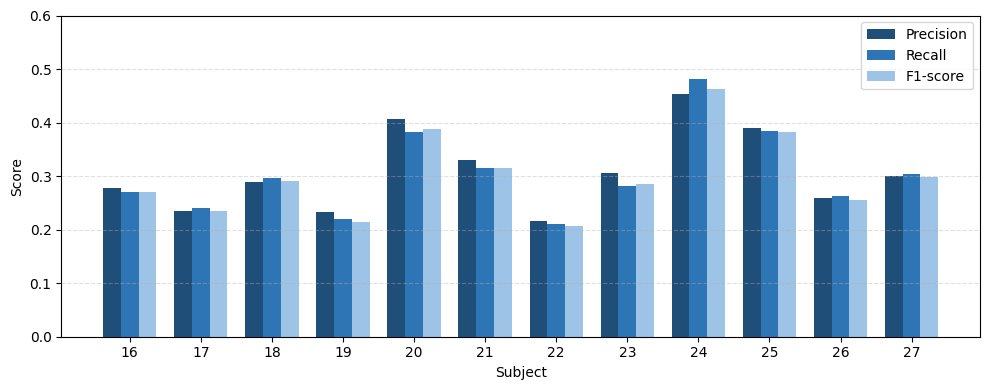

Saved plot: C:\Users\franc\Desktop\GitHub\05-Test_4_Cross_Subject_Adaptation\4.1_last_dense_only\results\prf_per_subject_blue.png


In [15]:
# ======= PLOT 1: Subjects on X, metrics on Y ======= #

# X axis: subjects numbered from 1 to N
x = np.arange(len(subjects))
x_labels = np.arange(16, 16+len(subjects))

width = 0.25

plt.figure(figsize=(10, 4))

plt.bar(
    x - width,
    precision,
    width,
    label="Precision",
    color="#1f4e79"   # dark blue
)

plt.bar(
    x,
    recall,
    width,
    label="Recall",
    color="#2e75b6"   # medium blue
)

plt.bar(
    x + width,
    f1_score_,
    width,
    label="F1-score",
    color="#9dc3e6"   # light blue
)

plt.xticks(x, x_labels)
plt.ylim(0, 0.6)
plt.ylabel("Score")
plt.xlabel("Subject")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save at high resolution for paper
plot_path = os.path.join(results_dir, "prf_per_subject_blue.png")
plt.savefig(plot_path, dpi=330)
plt.show()

print(f"Saved plot: {plot_path}")


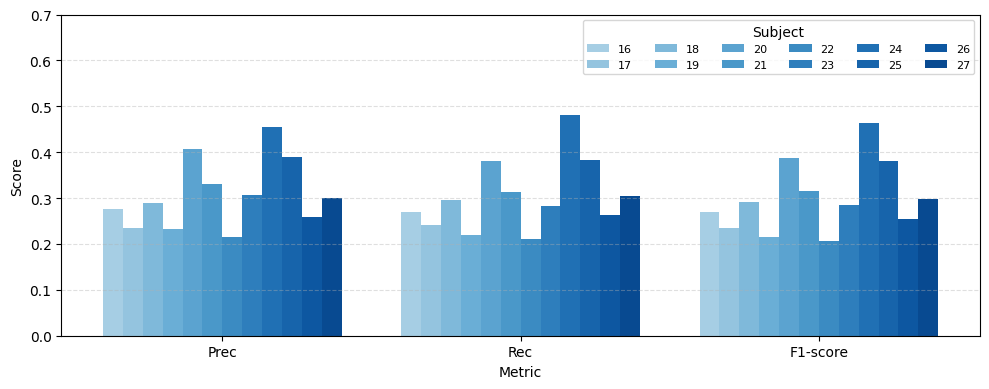

Saved plot: C:\Users\franc\Desktop\GitHub\05-Test_4_Cross_Subject_Adaptation\4.1_last_dense_only\results\prf_grouped_by_metric_blue.png


In [19]:
# ======= PLOT 2: Metrics on X, bars are subjects (blue scale, numeric subjects, save 330dpi) ======= #

import matplotlib.cm as cm
import matplotlib

metrics = ["Prec", "Rec", "F1-score"]
x = np.arange(len(metrics))

n_subj = len(subjects)

# Subject labels: 16–27
subj_labels = [str(i) for i in range(16, 16 + n_subj)]

bar_w = min(0.08, 0.8 / n_subj)  # width adaptable to number of subjects

# Blue shades (avoid too-light tones)
cmap = matplotlib.colormaps.get_cmap("Blues")
colors = [cmap(v) for v in np.linspace(0.35, 0.90, n_subj)]

plt.figure(figsize=(10, 4))

for i in range(n_subj):
    values = [precision[i], recall[i], f1_score_[i]]
    offset = (i - (n_subj - 1) / 2) * bar_w
    plt.bar(
        x + offset,
        values,
        bar_w,
        label=subj_labels[i],
        color=colors[i]
    )

plt.xticks(x, metrics)
plt.ylim(0, 0.7)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Subject", ncol=6, fontsize=8)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plot_path = os.path.join(results_dir, "prf_grouped_by_metric_blue.png")
plt.savefig(plot_path, dpi=330)
plt.show()

print(f"Saved plot: {plot_path}")
